In [4]:
import math
import random
import shutil
from datetime import datetime
from pathlib import Path
from urllib.request import urlretrieve

import PIL.Image as Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
from IPython.display import clear_output, display, HTML
from torchvision import transforms
from tqdm import tqdm_notebook as tqdm

pd.options.display.precision = 3
pd.options.display.max_rows = 10

In [5]:
%pip install -q \
    numpy==1.18.2 torch==1.4.0 torchvision==0.5.0 \
    tqdm==4.43.0 pillow==7.0.0 matplotlib==3.2.0 \
    pandas==1.0.1

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (pyproject.toml) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [6]:
torch.__version__

'2.10.0+cpu'

In [7]:
RANDOM_SEED = 123

random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

In [8]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [9]:
MAIN_ATTRIBUTE = 'Eyeglasses'
IMAGE_SIZE = 64

In [10]:
WORKING_DIR_PATH = Path('.')

IMAGES_ZIP_PATH = WORKING_DIR_PATH / 'img_align_celeba.zip'
IMAGES_DIR_PATH = IMAGES_ZIP_PATH.with_suffix('')
ANNOTATIONS_PATH = WORKING_DIR_PATH / 'list_attr_celeba.txt'
PARTITION_PATH = WORKING_DIR_PATH / 'list_eval_partition.txt'


CHECKPOINTS_PATH = WORKING_DIR_PATH / 'checkpoints'
ONNX_PATH = WORKING_DIR_PATH / 'classifier.onnx'

CHECKPOINTS_PATH.mkdir(exist_ok=True)

CELEBA_FACE_SIZE = 178

In [52]:
BATCH_SIZE = 64
EPOCHS = 2

LR = 1e-2
LR_DECAY_STEP = 7
LR_DECAY_GAMMA = 0.1
WEIGHT_DECAY = 1e-4

CONSISTENCY_WEIGHT = 0.1

NUM_WORKERS = 0

In [12]:
def copy_files_from_drive():
    DRIVE_PATH = WORKING_DIR_PATH / 'drive' / 'My Drive'
    from google.colab import drive
    drive.mount(str(DRIVE_PATH.parent))

    shutil.copy(DRIVE_PATH /'CelebA'/ 'Img'/ IMAGES_ZIP_PATH.name, IMAGES_ZIP_PATH)
    shutil.copy(DRIVE_PATH /'CelebA'/ 'Anno' /ANNOTATIONS_PATH.name, ANNOTATIONS_PATH)
    shutil.copy(DRIVE_PATH /'CelebA'/ 'Eval'/ PARTITION_PATH.name, PARTITION_PATH)

In [13]:
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


print("Downloading CelebA dataset from Kaggle...")
!kaggle datasets download -d jessicali9530/celeba-dataset

import zipfile
import os

print("Extracting files...")
with zipfile.ZipFile("celeba-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall(".")

if os.path.exists("list_attr_celeba.csv"):
    os.rename("list_attr_celeba.csv", "list_attr_celeba.txt")
if os.path.exists("list_eval_partition.csv"):
    os.rename("list_eval_partition.csv", "list_eval_partition.txt")

print("Dataset ready!")

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
celeba-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Extracting files...
Dataset ready!


In [14]:
if not IMAGES_DIR_PATH.exists():
    shutil.unpack_archive(str(IMAGES_ZIP_PATH), str(WORKING_DIR_PATH))

In [15]:

df_attr = pd.read_csv(ANNOTATIONS_PATH, index_col=0)

In [16]:
df_attr

,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,Blond_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
image_id,,,,,,,,,,,,,,,,,,,,,
000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202595.jpg,-1,-1,1,-1,-1,-1,1,-1,-1,1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1
202596.jpg,-1,-1,-1,-1,-1,1,1,-1,-1,1,...,-1,1,1,-1,-1,-1,-1,-1,-1,1
202597.jpg,-1,-1,-1,-1,-1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1


In [17]:
df_attr = df_attr[[MAIN_ATTRIBUTE]].replace({-1: 0})

In [18]:
df_attr

,Eyeglasses
image_id,
000001.jpg,0
000002.jpg,0
000003.jpg,0
000004.jpg,0
000005.jpg,0
...,...
202595.jpg,0
202596.jpg,0
202597.jpg,1


In [19]:
samples_with_glasses = list(df_attr[df_attr[MAIN_ATTRIBUTE] == 1].sample(25, random_state=RANDOM_SEED).index)
samples_without_glasses = list(df_attr[df_attr[MAIN_ATTRIBUTE] == 0].sample(25, random_state=RANDOM_SEED).index)

In [20]:
import os
from pathlib import Path

if os.path.exists('img_align_celeba/img_align_celeba'):
    IMAGES_DIR_PATH = Path('img_align_celeba/img_align_celeba')
else:
    IMAGES_DIR_PATH = Path('img_align_celeba')

def load_and_show(image_names, titles=None, directory=IMAGES_DIR_PATH):
    if titles is None:
        titles = image_names
    N = len(image_names)
    cols = int(math.sqrt(N))
    rows = int(math.ceil(N / cols))
    plt.figure(figsize=(12, 12))
    image_names_iter = iter(image_names)
    titles_iter = iter(titles)
    for r in range(rows):
        for c in range(cols):
            try:
                name = next(image_names_iter)
                title = next(titles_iter)
            except StopIteration:
                plt.show()
                return
            plt.subplot(rows, cols, cols * r + c + 1)

            with Image.open(directory / name) as image_pil:
                image = np.array(image_pil.convert('RGB'))
            plt.imshow(image)
            plt.axis('off')
            plt.title(title)

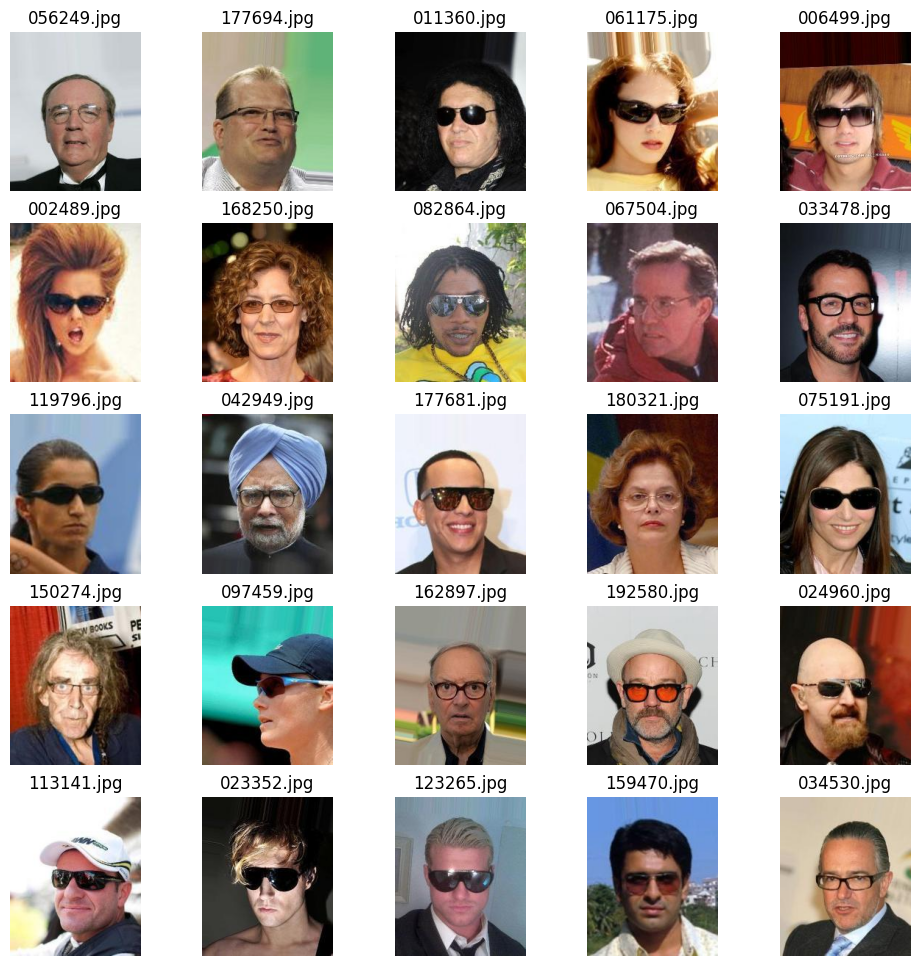

In [21]:
load_and_show(samples_with_glasses)

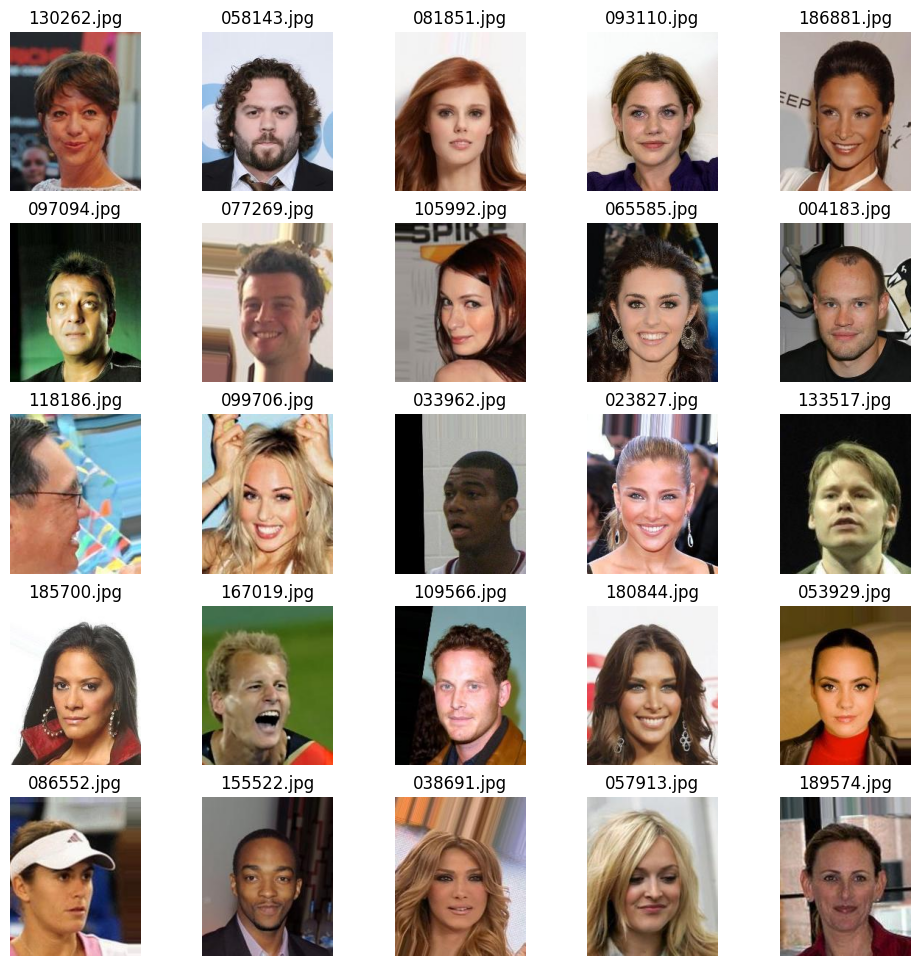

In [22]:
load_and_show(samples_without_glasses)

In [23]:
ratio = df_attr[MAIN_ATTRIBUTE].mean()
print(f'{MAIN_ATTRIBUTE}: {ratio * 100:0.2f} %')

Eyeglasses: 6.51 %


In [24]:

df_partition = pd.read_csv(PARTITION_PATH, index_col=0)

df_partition.columns = ['fold']

df_partition.fold.value_counts()

,count
fold,
0,162770
2,19962
1,19867


In [25]:
df_attr = df_attr.join(df_partition)

In [26]:
df_train = df_attr[df_attr.fold == 0]
df_valid = df_attr[df_attr.fold != 0]

In [27]:
def equalize(df, attribute):
    N = len(df)
    ones = df[attribute].sum()
    k = min(ones, N - ones)
    df_ones = df[df[attribute] == 1].sample(k)
    df_zeros = df[df[attribute] == 0].sample(k)
    index = list(df_ones.index) + list(df_zeros.index)
    random.shuffle(index)
    return df.loc[index]

In [28]:
df_train = equalize(df_train, MAIN_ATTRIBUTE)
df_valid = equalize(df_valid, MAIN_ATTRIBUTE)

In [29]:
crop_resize = transforms.Compose([
    transforms.CenterCrop(CELEBA_FACE_SIZE),
    transforms.Resize(IMAGE_SIZE),
])

transforms_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.2, hue=0.1),
    transforms.RandomAffine(3, scale=(0.95, 1.05)),
    transforms.ToTensor(),
])

transforms_valid = transforms.Compose([
    transforms.ToTensor(),
])

In [30]:
def load_images(df):
    images = []
    for image_name in tqdm(df.index, dynamic_ncols=True, leave=False):
        image_pil = Image.open(IMAGES_DIR_PATH / image_name)
        image = crop_resize(image_pil)
        images.append(image)
    return images

In [31]:
images_train = load_images(df_train)
images_valid = load_images(df_valid)

/tmp/ipykernel_3841/2935067833.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for image_name in tqdm(df.index, dynamic_ncols=True, leave=False):


  0%|          | 0/21042 [00:00<?, ?it/s]

  0%|          | 0/5344 [00:00<?, ?it/s]

In [32]:
class CelebaDataset(data.Dataset):
    def __init__(self, df, images, transforms=None):
        self.df = df
        self.images = images
        self.transforms = transforms

    def __getitem__(self, index):
        row = self.df.iloc[index]
        image_name = row.name
        attrs = row[MAIN_ATTRIBUTE]
        image = self.images[index]
        image_tensor = self.transforms(image)
        return image_tensor, attrs

    def __len__(self):
        return len(self.df)

In [33]:
def decode(tensor):
    return (tensor.cpu()
                  .clamp(0, 1)
                  .numpy()
                  .transpose((1, 2, 0)))

In [34]:
dataset_train = CelebaDataset(df_train, images_train, transforms_train)
dataset_valid = CelebaDataset(df_valid, images_valid, transforms_valid)

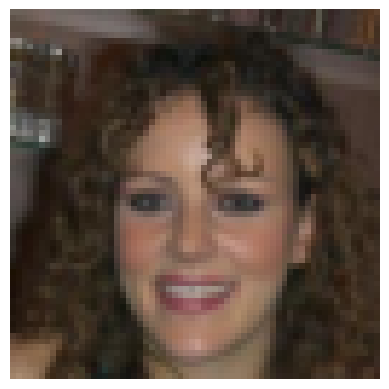

In [35]:
image, attrs = next(iter(dataset_valid))

plt.imshow(decode(image))
plt.axis('off')
plt.show()

In [36]:
def get_weights(arr):
    N = len(arr)
    ones = arr.sum()
    zeros = N - ones
    return (1 - arr) + arr * zeros / ones

In [37]:
weights_train = get_weights(df_train[MAIN_ATTRIBUTE].values)
weights_valid = get_weights(df_valid[MAIN_ATTRIBUTE].values)

In [38]:
loader_train = data.DataLoader(
    dataset_train,
    batch_size=BATCH_SIZE,
    sampler=data.WeightedRandomSampler(weights_train, len(df_train)),
    num_workers=NUM_WORKERS,
    drop_last=True)
loader_valid = data.DataLoader(
    dataset_valid,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    drop_last=False)

In [39]:
class SeparableConvBN(nn.Module):
    def __init__(self, channels_in, channels_out):
        super().__init__()
        self.blocks = nn.Sequential(
            nn.Conv2d(channels_in, channels_in,
                      kernel_size=3, padding=1,
                      groups=channels_in, bias=False),
            nn.BatchNorm2d(channels_in),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels_in, channels_out,
                      kernel_size=1, padding=0,
                      bias=False),
            nn.BatchNorm2d(channels_out),
        )

    def forward(self, x):
        return self.blocks(x)

In [40]:
class Downsample(nn.Module):
    def __init__(self, channels):
        super().__init__()

        a = np.array([1., 2., 1.], dtype=np.float32)
        a2 = a[:,None] * a[None,:]
        filt = torch.tensor(a2 / a2.sum())[None,None,:,:].repeat((channels,1,1,1))
        self.register_buffer('filt', filt)
        self.pad = nn.ReflectionPad2d([1, 1, 1, 1])
        self.channels = channels

    def forward(self, x):
        return F.conv2d(self.pad(x), self.filt, stride=2, groups=self.channels)

In [41]:
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()

        blocks = []

        blocks.extend([
            # 64x64
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            Downsample(16),

            # 32x32
            SeparableConvBN(16, 32),
            nn.ReLU(inplace=True),
            Downsample(32),

            # 16x16
            SeparableConvBN(32, 32),
            nn.ReLU(inplace=True),
            Downsample(32),

            # 8x8
            SeparableConvBN(32, 32),
            nn.ReLU(inplace=True),
            Downsample(32),

            # 4x4
            SeparableConvBN(32, 64),
            nn.ReLU(inplace=True),
            Downsample(64),

            nn.AdaptiveAvgPool2d(1),

            nn.Conv2d(64, 1, kernel_size=1, stride=1, padding=0),
            nn.Flatten(1),
        ])

        self.blocks = nn.Sequential(*blocks)

    def forward(self, x):
        return self.blocks(x)

In [42]:
model = Classifier()

In [43]:
bce = nn.BCEWithLogitsLoss()
mse = nn.MSELoss()

In [44]:
model = model.to(device)

In [45]:
def f1_score(conf_mat):
    tp = conf_mat[1, 1]
    fp = conf_mat[1, 0]
    fn = conf_mat[0, 1]
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1 = 2 * (precision * recall) / (precision + recall)
    return precision, recall, f1

In [46]:
def valid(loader=loader_valid):
    model.eval()
    confusion_matrix = np.zeros((2, 2), dtype=int)
    loss = 0
    pbar = tqdm(enumerate(loader), total=len(loader), dynamic_ncols=True, leave=False, desc='Validating')
    for i, (images, attrs) in pbar:
        images = images.to(device)
        with torch.no_grad():
            outputs = model(images)
            loss += bce(outputs, attrs.unsqueeze(1).to(device).float()).cpu().item()
        outputs = outputs.squeeze(1)
        preds = (outputs.cpu() > 0).int()
        for y_pred, y_true in zip(preds, attrs):
            confusion_matrix[y_true.item()][y_pred.item()] += 1
        precision, recall, f1 = f1_score(confusion_matrix)
        pbar.set_postfix({
            'Lclass': f'{loss / (i + 1):0.2f}',
            'F1': f'{f1:0.2f}',
            'Precision': f'{precision:0.2f}',
            'Recall': f'{recall:0.2f}',
        }, refresh=False)
    return loss / len(loader), precision, recall, f1, confusion_matrix

In [47]:
loss, precision, recall, f1, confusion_matrix = valid()
print(f'Loss: {loss:.3f}')

/tmp/ipykernel_3841/3615598207.py:5: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  pbar = tqdm(enumerate(loader), total=len(loader), dynamic_ncols=True, leave=False, desc='Validating')


Validating:   0%|          | 0/84 [00:00<?, ?it/s]

/tmp/ipykernel_3841/631285014.py:6: RuntimeWarning: invalid value encountered in scalar divide
  recall = tp / (tp + fn)


Loss: 0.693


In [48]:
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=LR_DECAY_STEP, gamma=LR_DECAY_GAMMA)

In [49]:
def random_change(images):
    pad = nn.ReflectionPad2d(1)
    images_padded = pad(images)
    outputs = []
    for i in range(images.size(0)):
        dx = random.randint(-1, 1)
        dy = random.randint(-1, 1)
        if dx == 0 and dy == 0:
            outputs.append(torch.flip(images[[i]], [-1]))
        else:
            h, w = image.shape[-2:]
            outputs.append(images_padded[[i], :, 1+dy:h+dy+1, 1+dx:w+dx+1])
    return torch.cat(outputs, 0)

In [50]:
def ema(new, old, alpha=0.6):
    if old is None or math.isnan(old):
        return new
    return alpha * new + (1 - alpha) * old

In [53]:
column_names = ['L_class_valid', 'L_class', 'L_cons', 'L_total', 'Precision', 'Recall', 'F1', 'LR']
stats = pd.DataFrame(columns=['Epoch', *column_names]).set_index('Epoch')
best_checkpoint = None
best_f1 = -1  # Fix for the max() error on the first epoch

for epoch in range(EPOCHS):
    metrics = pd.Series(index=column_names, dtype=float, name=epoch)

    model.train()
    pbar = tqdm(enumerate(loader_train), total=len(loader_train),
                dynamic_ncols=True, leave=False, desc=f'Epoch {epoch+1}/{EPOCHS}')

    for i, (images, attrs) in pbar:
        images = images.to(device)
        attrs = attrs.to(device).float().unsqueeze(1)

        outputs = model(images)
        outputs_changed = model(random_change(images))

        loss_classification = bce(outputs, attrs)
        loss_consistency = mse(outputs, outputs_changed)
        loss_total = loss_classification + CONSISTENCY_WEIGHT * loss_consistency

        optimizer.zero_grad()
        loss_total.backward()
        optimizer.step()

        metrics.L_class = ema(loss_classification.item(), metrics.get('L_class', None))
        metrics.L_cons = ema(loss_consistency.item(), metrics.get('L_cons', None))
        metrics.L_total = ema(loss_total.item(), metrics.get('L_total', None))

        lr = scheduler.get_last_lr()[0]
        pbar.set_postfix({
            'Lclass': f'{loss_classification.item():.3f}',
            'Lcons': f'{loss_consistency.item():.3f}',
            'LR': f'{lr:.0e}'
        }, refresh=False)

    loss_valid, precision, recall, f1, confusion_matrix = valid()
    scheduler.step()

    # Fixed the best checkpoint saving logic
    if best_checkpoint is None or f1 > best_f1:
        best_f1 = f1
        current_time = datetime.now().isoformat()
        best_checkpoint = CHECKPOINTS_PATH / f'classifier-{epoch}-{f1:0.2f}.pth'
        torch.save(model.state_dict(), best_checkpoint)

    metrics.L_class_valid = loss_valid
    metrics.F1 = f1
    metrics.Precision = precision
    metrics.Recall = recall
    metrics.LR = lr

    # Fixed the Pandas append error!
    stats.loc[epoch] = metrics

    clear_output(wait=True)
    display(HTML(stats.to_html()))

model.load_state_dict(torch.load(best_checkpoint))
model.eval()

print('Best checkpoint:', best_checkpoint)

,L_class_valid,L_class,L_cons,L_total,Precision,Recall,F1,LR
Epoch,,,,,,,,
0,0.153,0.090,0.244,0.114,0.905,0.983,0.943,0.01
1,0.106,0.163,0.203,0.184,0.979,0.947,0.963,0.01


Best checkpoint: checkpoints/classifier-1-0.96.pth


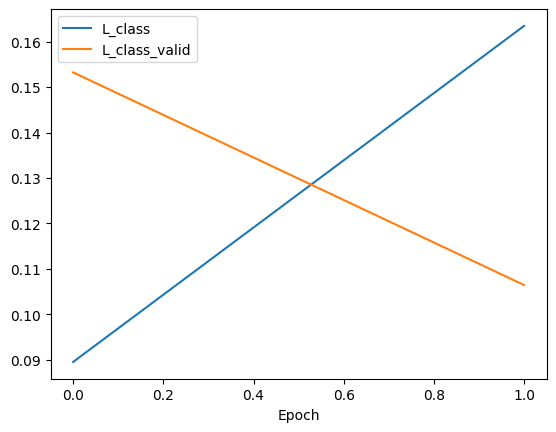

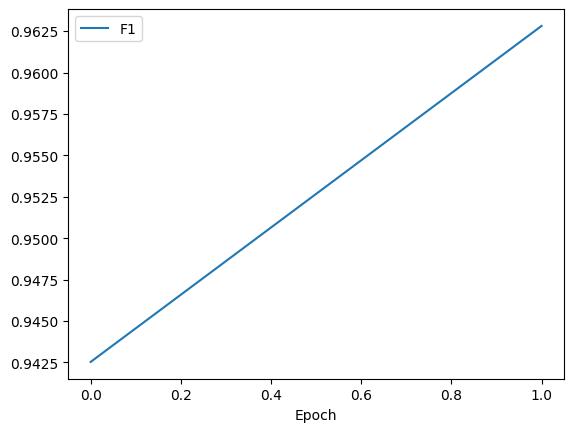

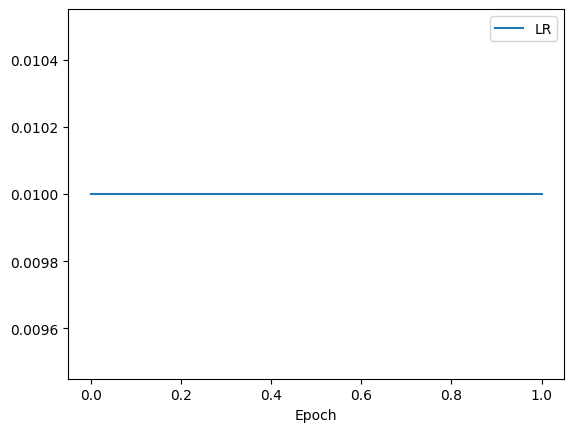

In [54]:
stats[['L_class', 'L_class_valid']].plot()
stats[['F1']].plot()
stats[['LR']].plot()
plt.show()

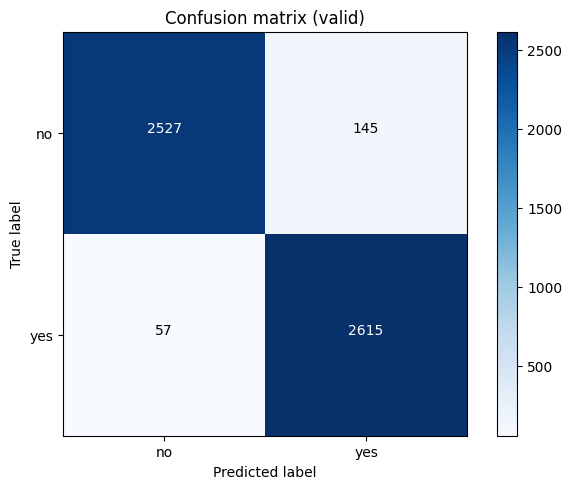

In [55]:
plt.figure()

plt.imshow(confusion_matrix, interpolation='nearest', cmap=plt.get_cmap('Blues'))

plt.title('Confusion matrix (valid)')
plt.colorbar()

plt.xticks([0, 1], ['no', 'yes'])
plt.yticks([0, 1], ['no', 'yes'])

threshold = confusion_matrix.max() / 2

for i in range(2):
    for j in range(2):
        plt.text(j, i, confusion_matrix[i, j],
                 horizontalalignment='center',
                 color='white' if confusion_matrix[i, j] > threshold else 'black')

plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()